## Import von Libraries

Libraries (oder Module) sind Sammlungen von bereits geschriebenem Code, die bestimmte Funktionen bereitstellen, z. B. für Mathematik, Datenverarbeitung oder Webzugriffe. Sie sind hilfreich, weil man dadurch nicht alles selbst programmieren muss, sondern auf getestete und oft optimierte Lösungen zurückgreifen kann, was Zeit spart und Fehler reduziert.

---

In Python importiert man Libraries mit dem import-Befehl, z.B. 
``` python 
import math
import pandas as pd
```
und kann dann auf deren Funktionen zugreifen. Alternativ kann man auch gezielt einzelne Bestandteile importieren, etwa mit 
```python
from math import sqrt.
```


![Bildschirmfoto 2026-03-19 um 12.17.09.png](<attachment:Bildschirmfoto 2026-03-19 um 12.17.09.png>)
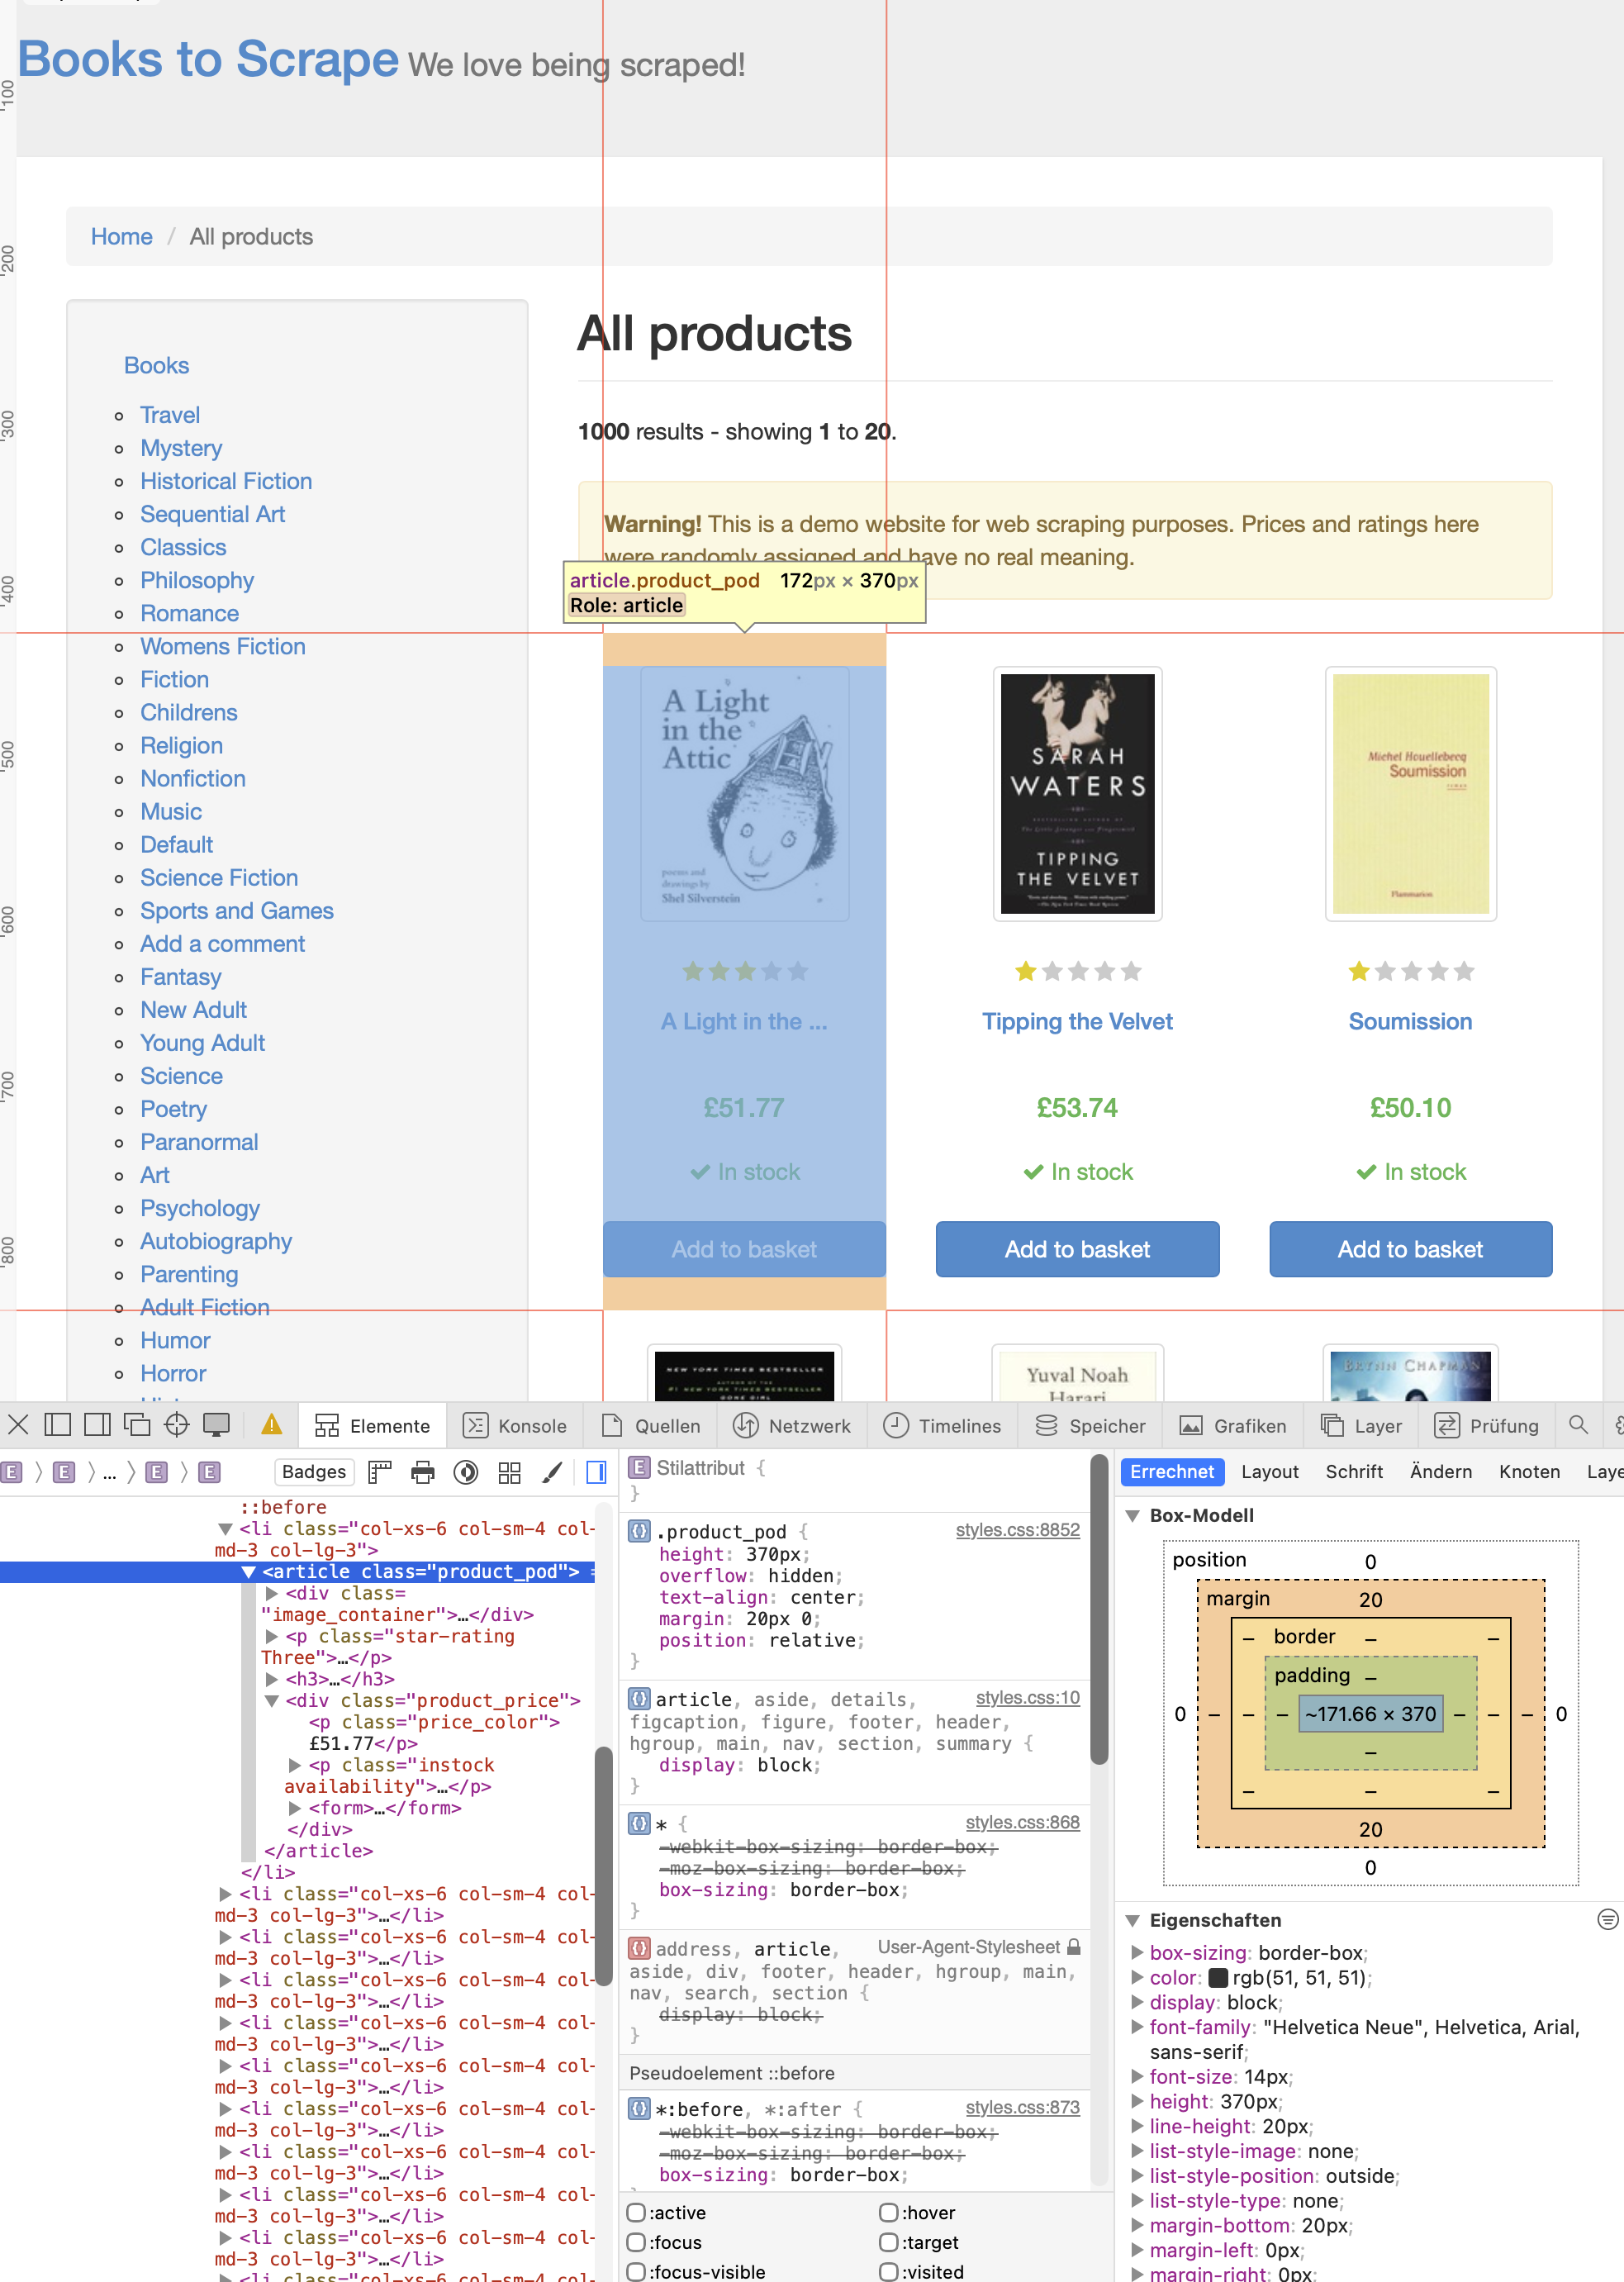

In [ ]:
import requests
from bs4 import BeautifulSoup
import time

url = "https://books.toscrape.com/catalogue/page-1.html"
response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

#print(soup)

erstes_buch = soup.find("article", class_="product_pod") # article ist das HTML-Element, das die Informationen über ein Buch enthält, und class_="product_pod" ist die Klasse, die dieses Element identifiziert.
print(erstes_buch.prettify()[:1000])  # nur ein Ausschnitt

In [ ]:
daten = []

for seite in range(1, 6):  # Seiten 1 bis 5
    url = f"https://books.toscrape.com/catalogue/page-{seite}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    buecher = soup.find_all("article", class_="product_pod") # Alle Einzelbücher befinden sich in einem Artikel-Tag mit der Klasse "product_pod"
    
    for buch in buecher:
        titel = buch.h3.a["title"] # Der Titel befindet sich im "title"-Attribut des "a"-Tags innerhalb des "h3"-Tags
        preis_text = buch.find("p", class_="price_color").text # Der Preis befindet sich in einem "p"-Tag mit der Klasse "price_color"
        rating = buch.find("p", class_="star-rating")["class"][1] # Das Rating befindet sich in einem "p"-Tag mit der Klasse "star-rating", die zweite Klasse gibt die Anzahl der Sterne an (z.B. "One", "Two", etc.)
        
        daten.append({ # hier entsteht eine Liste von Dictionaries, die die gesammelten Daten enthält --> Zweck: einfache Überführung in ein Dataframe
            "Titel": titel,
            "Preis": preis_text,
            "Rating": rating
        })
    
    print(f"Seite {seite} verarbeitet")
    time.sleep(1)  # kurze Pause zwischen den Requests

In [ ]:
daten

In [ ]:
#Daten in ein Pandas Dataframe überführen
import pandas as pd

df = pd.DataFrame(daten)
df


In [ ]:
# Daten bereinigen

#Bereinigung Preis
df["Preis"] = df["Preis"].str.replace("Â£", "").astype(float)

# Bereinigung Rating --> winnvoll, erst eien rating map anzulegen, da jeder Textwert einem bestimmten Zahlenwert entspricht
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Zahl"] = df["Rating"].map(rating_map)

df

In [ ]:
# Daten auswerten
auswertung = df.groupby("Rating_Zahl")["Preis"].mean().reset_index() # hier wird der Durchschnittspreis für jedes Rating berechnet
auswertung

In [ ]:
# Daten Plotten
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(auswertung["Rating_Zahl"], auswertung["Preis"])
plt.xlabel("Rating")
plt.ylabel("Durchschnittlicher Preis (in £)")
plt.title("Durchschnittlicher Buchpreis pro Rating")
plt.show()